In [1]:
from astropy.coordinates import SkyCoord, FK5
from astropy.time import Time
import astropy.units as u

# J2000 coordinates of Cygnus A
cygA_j2000 = SkyCoord(
    ra="19h59m28.3566s",
    dec="+40d44m02.096s",
    frame=FK5(equinox=Time("J2000"))
)

# Current epoch
current_time = Time.now()

# Transform to current epoch
cygA_now = cygA_j2000.transform_to(FK5(equinox=current_time))

cygA_j2000, cygA_now


(<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
     (299.8681525, 40.73391556)>,
 <SkyCoord (FK5: equinox=2026-01-19 16:51:59.686011): (ra, dec) in deg
     (300.09361921, 40.8063873)>)

In [ ]:
Question 1: Do RA and Dec change from J2000 to today?
Conceptual Explanation (Markdown cell)

Right Ascension (RA) and Declination (Dec) of astronomical sources are usually published for a standard reference epoch, most commonly J2000.0 (January 1, 2000).

Due to:

Precession of Earth’s rotation axis

Nutation

Proper motion (very small for distant radio galaxies like Cygnus A)

The observed RA and Dec today are slightly different from their J2000 values.

Using Astropy, we can transform coordinates from the FK5 J2000 frame to the current epoch.

Cygnus A is a distant radio galaxy, so proper motion is negligible, but precession causes measurable coordinate changes.

In [2]:
from astropy.coordinates import EarthLocation, AltAz
from astropy.time import Time

# IIT Kanpur location
iitk = EarthLocation(
    lat=26.5123*u.deg,
    lon=80.2329*u.deg,
    height=142*u.m
)

# Observation time
obs_time = Time.now()

# AltAz frame
altaz_frame = AltAz(obstime=obs_time, location=iitk)

# Convert coordinates
cygA_altaz = cygA_j2000.transform_to(altaz_frame)

cygA_altaz.az, cygA_altaz.alt


(<Longitude 338.58487963 deg>, <Latitude -18.07305541 deg>)

In [ ]:
Question 2: Azimuth and Elevation from IIT Kanpur
Conceptual Explanation (Markdown cell)

Azimuth and Elevation depend on:

Observer’s location

Time of observation

IIT Kanpur coordinates:

Latitude ≈ 26.5123° N

Longitude ≈ 80.2329° E

We use the AltAz frame in Astropy.

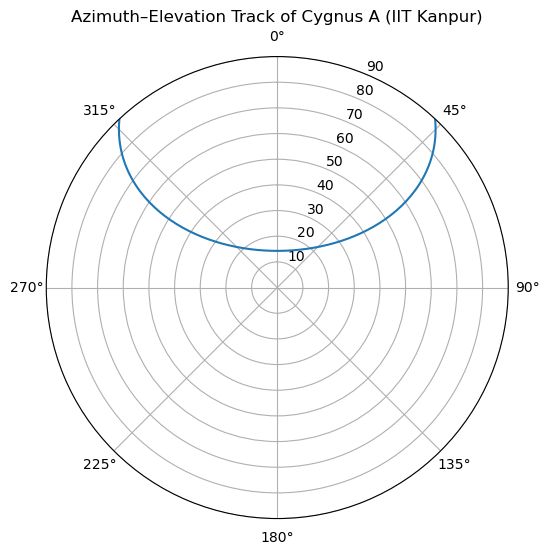

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Time range: 24 hours
times = obs_time + np.linspace(0, 24, 200)*u.hour

# Transform for each time
altaz_coords = cygA_j2000.transform_to(
    AltAz(obstime=times, location=iitk)
)

# Polar plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(
    altaz_coords.az.rad,
    90 - altaz_coords.alt.deg
)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlim(0, 90)
ax.set_title("Azimuth–Elevation Track of Cygnus A (IIT Kanpur)")

plt.show()


In [ ]:
Question 3: Polar Plot of Azimuth–Elevation Variation
Conceptual Explanation (Markdown cell)

Over 24 hours, Earth’s rotation causes:

Azimuth to sweep 0–360°

Elevation to rise and fall

A polar plot is ideal for visualizing sky motion.

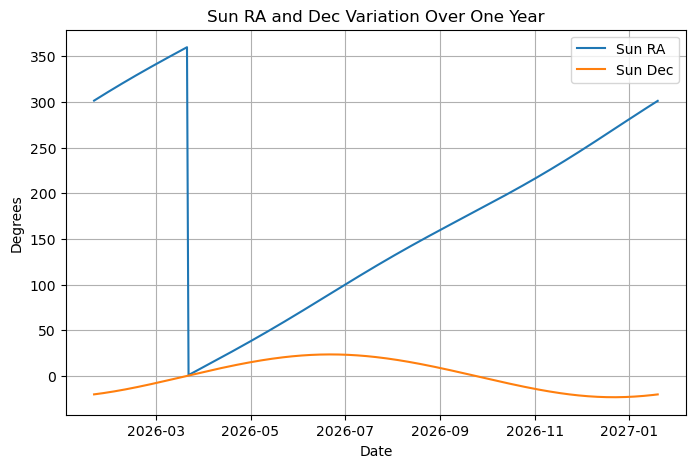

In [4]:
from astropy.coordinates import get_sun

# One year time range
year_times = Time.now() + np.linspace(0, 365, 365)*u.day

sun_coords = get_sun(year_times)

plt.figure(figsize=(8,5))
plt.plot(year_times.datetime, sun_coords.ra.deg, label="Sun RA")
plt.plot(year_times.datetime, sun_coords.dec.deg, label="Sun Dec")

plt.xlabel("Date")
plt.ylabel("Degrees")
plt.title("Sun RA and Dec Variation Over One Year")
plt.legend()
plt.grid()
plt.show()


In [ ]:
Question 4: Sun’s RA–Dec Variation vs Cygnus A
Conceptual Explanation (Markdown cell)

The Sun’s RA and Dec change continuously due to:

Earth’s orbital motion

Obliquity of ecliptic (~23.5°)

Cygnus A:

Fixed RA–Dec (apart from tiny precession effects)

We compute Sun’s coordinates for one full year.